In [1]:
import os
os.listdir()


['.ipynb_checkpoints',
 'ECG5000_TEST.txt',
 'ECG5000_TRAIN.txt',
 'Week4-ccn.ipynb']

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, ReLU, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical


In [4]:
# Load ECG5000 dataset
train_data = np.loadtxt("ECG5000_TRAIN.txt")
test_data = np.loadtxt("ECG5000_TEST.txt")

X_train = train_data[:, 1:]
y_train = train_data[:, 0].astype(int) - 1

X_val = test_data[:, 1:]
y_val = test_data[:, 0].astype(int) - 1

num_classes = len(np.unique(y_train))

# One-hot encoding
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)


In [5]:
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_val = (X_val - np.mean(X_val)) / np.std(X_val)


In [6]:

  from tensorflow.keras.layers import Input

def build_model(hidden_layers=2, activation="relu", optimizer="adam", lr=0.001):
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Flatten())

    for _ in range(hidden_layers):
        model.add(Dense(128))
        if activation == "relu":
            model.add(ReLU())
        else:
            model.add(LeakyReLU(alpha=0.1))

    model.add(Dense(num_classes, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



In [7]:
experiments = [
    {"layers": 2, "activation": "relu", "optimizer": "adam"},
    {"layers": 3, "activation": "relu", "optimizer": "adam"},
    {"layers": 2, "activation": "leakyrelu", "optimizer": "adam"},
    {"layers": 2, "activation": "relu", "optimizer": "sgd"},
]

results = []

for exp in experiments:
    model = build_model(
        hidden_layers=exp["layers"],
        activation=exp["activation"],
        optimizer=exp["optimizer"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        verbose=0
    )

    results.append({
        "Hidden layers": exp["layers"],
        "Activation": exp["activation"],
        "Optimizer": exp["optimizer"],
        "Validation accuracy": history.history["val_accuracy"][-1]
    })


C:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [8]:
results_df = pd.DataFrame(results)
results_df


,Hidden layers,Activation,Optimizer,Validation accuracy
0,2,relu,adam,0.938222
1,3,relu,adam,0.940000
2,2,leakyrelu,adam,0.935333
3,2,relu,sgd,0.909778


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, ReLU, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# Adding the channel for CNN 1D
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]


In [11]:
# Labels entiers (AVANT one-hot)
y_train_int = train_data[:, 0].astype(int) - 1
y_val_int   = test_data[:, 0].astype(int) - 1


In [12]:
def build_cnn_model(optimizer="adam", lr=0.001):
    model = Sequential()

    model.add(Conv1D(16, kernel_size=5, padding="same",
                     input_shape=X_train_cnn.shape[1:]))
    model.add(ReLU())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(32, kernel_size=5, padding="same"))
    model.add(ReLU())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [13]:
print("num_classes =", num_classes)
print("y_train shape =", y_train.shape)


num_classes = 5
y_train shape = (500, 5)


In [14]:
num_classes = len(np.unique(y_train_int))
print("num_classes =", num_classes)


num_classes = 5


In [15]:
y_train = to_categorical(y_train_int, num_classes)
y_val   = to_categorical(y_val_int, num_classes)

print("y_train shape =", y_train.shape)


y_train shape = (500, 5)


In [16]:
cnn_model = build_cnn_model(optimizer="adam")

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)


Epoch 1/15


C:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8120 - loss: 0.8967 - val_accuracy: 0.9098 - val_loss: 0.3951
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9280 - loss: 0.3358 - val_accuracy: 0.9176 - val_loss: 0.3002
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9340 - loss: 0.2555 - val_accuracy: 0.9316 - val_loss: 0.2535
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9420 - loss: 0.2173 - val_accuracy: 0.9313 - val_loss: 0.2315
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9420 - loss: 0.1870 - val_accuracy: 0.9338 - val_loss: 0.2272
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9540 - loss: 0.1645 - val_accuracy: 0.9344 - val_loss: 0.2146
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9480 - loss: 0.1510 - val_accuracy: 0.9373 - val_loss: 0.2330
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9620 - loss: 0.1349 - val_accuracy: 0.9407 - val_loss: 0.

In [17]:
print("num_classes =", num_classes)
cnn_model.summary()


num_classes = 5


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 140, 16)             │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_7 (ReLU)                       │ (None, 140, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 70, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 70, 32)              │           2,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_8 (ReLU)                       │ (None, 70, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 35, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │          71,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 224,273 (876.07 KB)

 Trainable params: 74,757 (292.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 149,516 (584.05 KB)

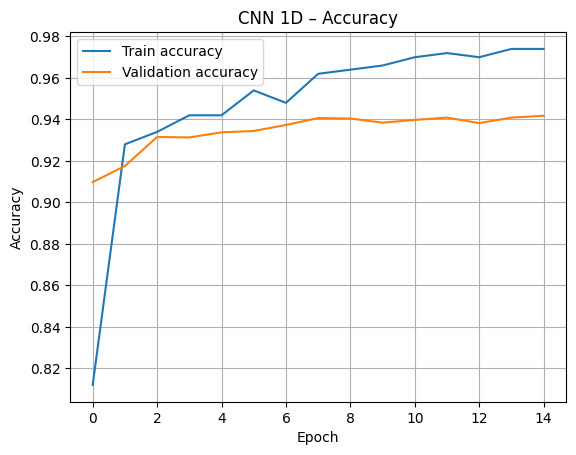

In [18]:
plt.figure()
plt.plot(history_cnn.history["accuracy"], label="Train accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN 1D – Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
cnn_val_acc = history_cnn.history["val_accuracy"][-1]

new_row = pd.DataFrame([{
    "Hidden layers": "CNN",
    "Activation": "ReLU",
    "Optimizer": "Adam",
    "Validation accuracy": cnn_val_acc
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)

results_df


,Hidden layers,Activation,Optimizer,Validation accuracy
0,2,relu,adam,0.938222
1,3,relu,adam,0.940000
2,2,leakyrelu,adam,0.935333
3,2,relu,sgd,0.909778
4,CNN,ReLU,Adam,0.941778


In [20]:
y_val_pred = cnn_model.predict(X_val_cnn)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true = np.argmax(y_val, axis=1)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


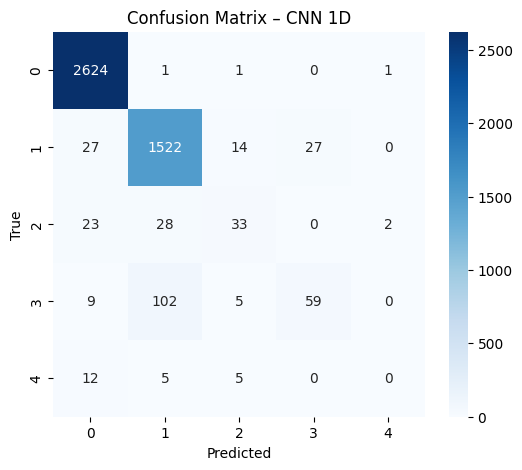

In [21]:
cm = confusion_matrix(y_val_true, y_val_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – CNN 1D")
plt.show()


In [22]:
print(classification_report(
    y_val_true,
    y_val_pred_classes,
    zero_division=0
))



              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2627
           1       0.92      0.96      0.94      1590
           2       0.57      0.38      0.46        86
           3       0.69      0.34      0.45       175
           4       0.00      0.00      0.00        22

    accuracy                           0.94      4500
   macro avg       0.63      0.54      0.57      4500
weighted avg       0.93      0.94      0.93      4500



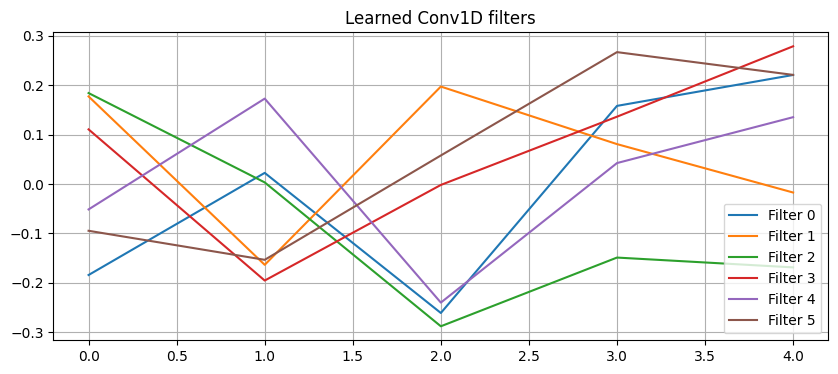

In [23]:
filters = cnn_model.layers[0].get_weights()[0]

plt.figure(figsize=(10, 4))
for i in range(min(6, filters.shape[-1])):
    plt.plot(filters[:, 0, i], label=f"Filter {i}")
plt.title("Learned Conv1D filters")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
misclassified = np.where(y_val_pred_classes != y_val_true)[0]
print("Misclassified samples:", len(misclassified))


Misclassified samples: 262


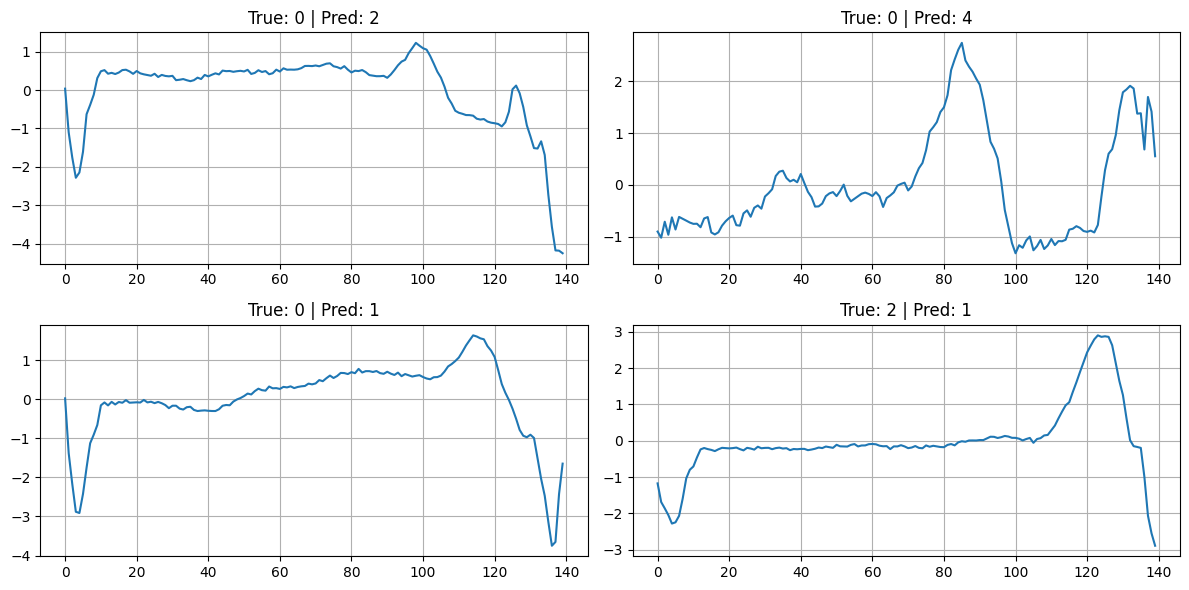

In [25]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified[:4]):
    plt.subplot(2, 2, i+1)
    plt.plot(X_val[idx])
    plt.title(f"True: {y_val_true[idx]} | Pred: {y_val_pred_classes[idx]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


In [26]:
The 1D CNN outperforms the MLP in validation accuracy.
Thanks to convolutional layers, the CNN captures local temporal patterns
in ECG signals, improving robustness to noise and morphological variations.
Error analysis shows that misclassified signals often present ambiguous shapes
or overlapping characteristics between classes.


SyntaxError: invalid decimal literal (2741250871.py, line 1)